In [2]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
import os, re, json, math, random
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False  # faster
    torch.backends.cudnn.benchmark = True       # faster

seed_everything(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Torch:", torch.__version__)
print("Device:", device)

Torch: 2.10.0+cu128
Device: cuda


Load CSVs from Drive + split sanity checks

In [3]:
DATA_DIR = "/content/drive/MyDrive/TASK01/data/"

TRAIN_CSV = os.path.join(DATA_DIR, "train_event_gap_reduced.csv")
DEV_CSV   = os.path.join(DATA_DIR, "dev_event_gap_reduced.csv")
TEST_CSV  = os.path.join(DATA_DIR, "test_event_gap_reduced.csv")

train_df = pd.read_csv(TRAIN_CSV)
dev_df   = pd.read_csv(DEV_CSV)
test_df  = pd.read_csv(TEST_CSV)

TEXT_COL  = "tweet_text"
LABEL_COL = "event_name"

print("Train:", train_df.shape)
print("Dev  :", dev_df.shape)
print("Test :", test_df.shape)
print("Columns:", list(train_df.columns))

assert TEXT_COL in train_df.columns, f"Missing {TEXT_COL}"
assert LABEL_COL in train_df.columns, f"Missing {LABEL_COL}"

for name, df in [("train", train_df), ("dev", dev_df), ("test", test_df)]:
    assert df[TEXT_COL].isna().sum() == 0, f"{name} has NaN text"
    assert df[LABEL_COL].isna().sum() == 0, f"{name} has NaN label"
    print(f"{name} label counts:\n", df[LABEL_COL].value_counts(), "\n")

Train: (940, 6)
Dev  : (217, 6)
Test : (146, 6)
Columns: ['event_name', 'tweet_id', 'image_id', 'tweet_text', 'image', 'label']
train label counts:
 event_name
hurricane     285
earthquake    239
wildfires     235
floods        181
Name: count, dtype: int64 

dev label counts:
 event_name
earthquake    60
hurricane     60
wildfires     56
floods        41
Name: count, dtype: int64 

test label counts:
 event_name
hurricane     45
wildfires     38
earthquake    35
floods        28
Name: count, dtype: int64 



Label mapping (fixed label set + robust mapping)

In [4]:
EXPECTED_LABELS = ["earthquake", "floods", "hurricane", "wildfires"]

train_labels = sorted(train_df[LABEL_COL].unique().tolist())
dev_labels   = sorted(dev_df[LABEL_COL].unique().tolist())
test_labels  = sorted(test_df[LABEL_COL].unique().tolist())

print("Unique labels train:", train_labels)
print("Unique labels dev  :", dev_labels)
print("Unique labels test :", test_labels)

assert sorted(EXPECTED_LABELS) == train_labels, "Train labels differ from expected!"
assert sorted(EXPECTED_LABELS) == dev_labels,   "Dev labels differ from expected!"
assert sorted(EXPECTED_LABELS) == test_labels,  "Test labels differ from expected!"

# fixed mapping order (research reproducibility)
label2id = {lbl:i for i,lbl in enumerate(EXPECTED_LABELS)}
id2label = {i:lbl for lbl,i in label2id.items()}

train_df["label_id"] = train_df[LABEL_COL].map(label2id)
dev_df["label_id"]   = dev_df[LABEL_COL].map(label2id)
test_df["label_id"]  = test_df[LABEL_COL].map(label2id)

assert train_df["label_id"].isna().sum() == 0
assert dev_df["label_id"].isna().sum() == 0
assert test_df["label_id"].isna().sum() == 0

print("Label mapping:", label2id)

Unique labels train: ['earthquake', 'floods', 'hurricane', 'wildfires']
Unique labels dev  : ['earthquake', 'floods', 'hurricane', 'wildfires']
Unique labels test : ['earthquake', 'floods', 'hurricane', 'wildfires']
Label mapping: {'earthquake': 0, 'floods': 1, 'hurricane': 2, 'wildfires': 3}


Tweet preprocessing (domain-correct, not destructive)

In [5]:
!pip -q install emoji
import re, html, unicodedata
import emoji

URL_RE  = re.compile(r"(http\S+|www\.\S+)", re.IGNORECASE)
USER_RE = re.compile(r"@\w+")
NUM_RE  = re.compile(r"\b\d+(\.\d+)?\b")
WS_RE   = re.compile(r"\s+")

# reduce extreme repeats but keep signal
PUNCT_REPEAT_RE = re.compile(r"([!?.,])\1{2,}")   # "!!!!!" -> "!!"
CHAR_REPEAT_RE  = re.compile(r"(.)\1{3,}")        # "soooo" -> "soo"

def clean_tweet(text: str) -> str:
    text = str(text)

    # 1) Fix HTML artifacts like &gt; &amp; etc.
    text = html.unescape(text)

    # 2) Normalize unicode (smart quotes, dashes, compatibility chars)
    text = unicodedata.normalize("NFKC", text)
    text = (text.replace("’", "'")
                .replace("“", '"').replace("”", '"')
                .replace("–", "-").replace("—", "-")
                .replace("…", "..."))

    # 3) Normalize URLs / mentions
    text = URL_RE.sub(" <URL> ", text)
    text = USER_RE.sub(" <USER> ", text)

    # 4) Keep hashtag word (don’t delete it)
    text = re.sub(r"#(\w+)", r" <HASHTAG> \1 ", text)

    # 5) Emoji to text tokens
    text = emoji.demojize(text, delimiters=(" ", " "))

    # 6) Numbers
    text = NUM_RE.sub(" <NUM> ", text)

    # 7) Reduce repeats (keep emphasis but avoid extreme variants)
    text = PUNCT_REPEAT_RE.sub(r"\1\1", text)
    text = CHAR_REPEAT_RE.sub(r"\1\1", text)

    # 8) Lowercase for custom tokenizer
    text = text.lower()

    # 9) Clean whitespace/control chars
    text = re.sub(r"[\r\n\t]", " ", text)
    text = WS_RE.sub(" ", text).strip()

    return text

train_df["clean_text"] = train_df[TEXT_COL].apply(clean_tweet)
dev_df["clean_text"]   = dev_df[TEXT_COL].apply(clean_tweet)
test_df["clean_text"]  = test_df[TEXT_COL].apply(clean_tweet)

# sanity checks
assert train_df["clean_text"].isna().sum() == 0
assert dev_df["clean_text"].isna().sum() == 0
assert test_df["clean_text"].isna().sum() == 0
assert train_df["clean_text"].str.len().min() > 0

# spot check: verify HTML artifacts removed
sample = train_df[[TEXT_COL, "clean_text", LABEL_COL]].sample(20, random_state=7)
print(sample)

# optional: quick check for any leftover &gt; or &amp;
leftovers = train_df["clean_text"].str.contains(r"&gt;|&amp;|&lt;", regex=True).sum()
print("HTML leftovers in clean_text:", leftovers)

                                            tweet_text  \
357  Frida, the dog that uses sense of smell to loc...   
915  Eye of the storm: 'Hurricane Hunters' fly thro...   
649  Without insurance, Harvey's victims turn towar...   
732  Harvey Destroyed Houston’s Cars–This Program I...   
98   Wildfires chase Barry Bonds and other prominen...   
323  Sri Lanka whales beached after Cyclone Mora ht...   
613  #breakingnews #news Southern California Wildfi...   
888  NASA Satellites Monitor California's Blazing W...   
551  Many 1st responders are helping Harvey victims...   
858  Sri Lanka struggles to deliver aid to stranded...   
776  @FoxNews @POTUS 2/ Obama responding to Colorad...   
939  More rain can be expected. #floodsl https://t....   
897  Irma and Our Age of Standardized Disaster http...   
13   Series&gt; In the Wake of Hurricane Harvey, Ne...   
760  Journalists double as rescuers during Harvey h...   
60   RT @Breaking911: IRMA: HURRICANE CONDITIONS SP...   
565  7.1 earth

Save cleaned CSVs (optional, but matches your pipeline style)

In [ ]:
train_clean_path = os.path.join(DATA_DIR, "train_4class_clean_custom.csv")
dev_clean_path   = os.path.join(DATA_DIR, "dev_4class_clean_custom.csv")
test_clean_path  = os.path.join(DATA_DIR, "test_4class_clean_custom.csv")

train_df.to_csv(train_clean_path, index=False)
dev_df.to_csv(dev_clean_path, index=False)
test_df.to_csv(test_clean_path, index=False)

print("Saved cleaned CSVs:\n", train_clean_path, "\n", dev_clean_path, "\n", test_clean_path)

Train SentencePiece BPE tokenizer (research contribution)

In [6]:
# ====== REPLACE: SentencePiece BPE tokenizer cell ======
!pip -q install sentencepiece
import sentencepiece as spm
import os

SP_DIR = "/content/drive/MyDrive/TASK01/models/spm_tokenizer_4class"
os.makedirs(SP_DIR, exist_ok=True)

spm_prefix = os.path.join(SP_DIR, "tweet_bpe")

corpus_path = os.path.join(SP_DIR, "spm_train_corpus.txt")
with open(corpus_path, "w", encoding="utf-8") as f:
    for t in train_df["clean_text"].tolist():
        f.write(str(t).replace("\n", " ") + "\n")

vocab_try_list = [16000, 12000, 10000, 8000, 6000, 4000]

VOCAB_SIZE = None
last_err = None

for vs in vocab_try_list:
    try:
        print(f"Trying vocab_size={vs}")
        spm.SentencePieceTrainer.train(
            input=corpus_path,
            model_prefix=spm_prefix,
            vocab_size=vs,
            model_type="bpe",
            character_coverage=1.0,
            pad_id=0, unk_id=1, bos_id=2, eos_id=3
        )
        VOCAB_SIZE = vs
        print(f"✅ Trained with vocab_size={VOCAB_SIZE}")
        break
    except RuntimeError as e:
        last_err = e
        print(f"❌ Failed vocab_size={vs}: {e}")

if VOCAB_SIZE is None:
    raise RuntimeError(f"SentencePiece training failed for all vocab sizes. Last error: {last_err}")

sp = spm.SentencePieceProcessor()
sp.load(spm_prefix + ".model")

print("Final vocab size (actual):", sp.get_piece_size())
print("Example pieces:", sp.encode_as_pieces(train_df["clean_text"].iloc[0])[:35])

Trying vocab_size=16000
❌ Failed vocab_size=16000: Internal: src/trainer_interface.cc(664) [(trainer_spec_.vocab_size()) == (model_proto->pieces_size())] Vocabulary size too high (16000). Please set it to a value <= 11335.
Trying vocab_size=12000
❌ Failed vocab_size=12000: Internal: src/trainer_interface.cc(664) [(trainer_spec_.vocab_size()) == (model_proto->pieces_size())] Vocabulary size too high (12000). Please set it to a value <= 11335.
Trying vocab_size=10000
✅ Trained with vocab_size=10000
Final vocab size (actual): 10000
Example pieces: ['▁busy', '▁day', ',', '▁chasing', '▁storm', '▁damage', '▁in', '▁richland', '▁co', '.', '▁a', '▁mother', '▁and', '▁<', 'num', '>', '▁yr', '-', 'old', '▁were', '▁sucked', '▁out', '▁of', '▁a', '▁home', '▁by', '▁winds', '▁or', '▁tornado', '.', '▁<', 'url', '>']


Auto choose MAX_LEN from TRAIN tokens (important for accuracy)

This avoids guessing MAX_LEN.

In [7]:
PAD_ID, UNK_ID, BOS_ID, EOS_ID = 0, 1, 2, 3

def sp_len(s: str) -> int:
    return len(sp.encode_as_ids(s)) + 2  # +BOS/EOS

lengths = train_df["clean_text"].apply(sp_len).values
p50 = int(np.percentile(lengths, 50))
p90 = int(np.percentile(lengths, 90))
p95 = int(np.percentile(lengths, 95))
p99 = int(np.percentile(lengths, 99))
mx  = int(lengths.max())

print({"p50": p50, "p90": p90, "p95": p95, "p99": p99, "max": mx})

# Accuracy-oriented: keep most info but not too large for T4
MAX_LEN = min(256, max(96, p95))
print("Chosen MAX_LEN =", MAX_LEN)

{'p50': 24, 'p90': 34, 'p95': 37, 'p99': 45, 'max': 64}
Chosen MAX_LEN = 96


Dataset + dynamic padding collate

In [8]:
def encode_text(s: str, max_len: int):
    ids = [BOS_ID] + sp.encode_as_ids(s) + [EOS_ID]
    ids = ids[:max_len]
    attn = [1]*len(ids)
    return ids, attn

class TweetSPDataset(Dataset):
    def __init__(self, df, max_len):
        self.texts = df["clean_text"].tolist()
        self.labels = df["label_id"].astype(int).tolist()
        self.max_len = max_len

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        ids, attn = encode_text(self.texts[idx], self.max_len)
        return {
            "input_ids": torch.tensor(ids, dtype=torch.long),
            "attention_mask": torch.tensor(attn, dtype=torch.long),
            "labels": torch.tensor(self.labels[idx], dtype=torch.long),
        }

def collate_batch(batch):
    maxL = max(x["input_ids"].shape[0] for x in batch)
    input_ids, attn, labels = [], [], []
    for x in batch:
        ids = x["input_ids"]
        m   = x["attention_mask"]
        pad_len = maxL - ids.shape[0]
        if pad_len > 0:
            ids = torch.cat([ids, torch.full((pad_len,), PAD_ID, dtype=torch.long)])
            m   = torch.cat([m, torch.zeros((pad_len,), dtype=torch.long)])
        input_ids.append(ids)
        attn.append(m)
        labels.append(x["labels"])
    return {
        "input_ids": torch.stack(input_ids),
        "attention_mask": torch.stack(attn),
        "labels": torch.stack(labels),
    }

train_ds = TweetSPDataset(train_df, MAX_LEN)
dev_ds   = TweetSPDataset(dev_df, MAX_LEN)
test_ds  = TweetSPDataset(test_df, MAX_LEN)

s = train_ds[0]
print("sample len:", len(s["input_ids"]), "label:", s["labels"].item(), id2label[s["labels"].item()])

sample len: 35 label: 2 hurricane


Custom Transformer model (clear layers)

In [9]:
import torch
import torch.nn as nn

class TransformerEncoderBlock(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.attn = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=n_heads,
            dropout=dropout,
            batch_first=True
        )
        self.drop1 = nn.Dropout(dropout)

        self.ln2 = nn.LayerNorm(d_model)
        self.ff = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model)
        )
        self.drop2 = nn.Dropout(dropout)

    def forward(self, x, key_padding_mask: torch.Tensor):
        # key_padding_mask: [B,T] bool, True for PAD
        h = self.ln1(x)
        attn_out, _ = self.attn(h, h, h, key_padding_mask=key_padding_mask, need_weights=False)
        x = x + self.drop1(attn_out)

        h = self.ln2(x)
        x = x + self.drop2(self.ff(h))
        return x


class DisasterTweetTransformer(nn.Module):
    def __init__(self, vocab_size, num_classes, max_len,
                 d_model=320, n_layers=6, n_heads=8, d_ff=1280, dropout=0.15):
        super().__init__()
        self.max_len = max_len
        self.tok_emb = nn.Embedding(vocab_size, d_model, padding_idx=PAD_ID)
        self.pos_emb = nn.Embedding(max_len, d_model)
        self.drop = nn.Dropout(dropout)

        self.blocks = nn.ModuleList([
            TransformerEncoderBlock(d_model, n_heads, d_ff, dropout)
            for _ in range(n_layers)
        ])
        self.ln = nn.LayerNorm(d_model)

        # attentive pooling
        self.pool_score = nn.Linear(d_model, 1)

        self.classifier = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, num_classes),
        )

    def forward(self, input_ids, attention_mask):
        # input_ids: [B,T], attention_mask: [B,T] (1 for token, 0 for pad)
        B, T = input_ids.shape

        # ✅ Safety: ensure T never exceeds pos_emb size
        # This should not happen if you encoded with MAX_LEN,
        # but this prevents "index out of range" crashes.
        if T > self.max_len:
            input_ids = input_ids[:, :self.max_len]
            attention_mask = attention_mask[:, :self.max_len]
            T = self.max_len

        pos = torch.arange(T, device=input_ids.device).unsqueeze(0).expand(B, T)

        x = self.tok_emb(input_ids) + self.pos_emb(pos)
        x = self.drop(x)

        key_padding_mask = (attention_mask == 0).bool()  # [B,T] True for PAD

        for blk in self.blocks:
            x = blk(x, key_padding_mask)

        x = self.ln(x)

        scores = self.pool_score(x).squeeze(-1)  # [B,T]

        # ✅ AMP-safe masking
        # Use a safe negative value for fp16 so no overflow occurs.
        if scores.dtype == torch.float16:
            mask_value = -1e4
        else:
            mask_value = -1e9

        scores = scores.masked_fill(key_padding_mask, mask_value)
        w = torch.softmax(scores, dim=1).unsqueeze(-1)   # [B,T,1]
        pooled = torch.sum(x * w, dim=1)                 # [B,d_model]

        return self.classifier(pooled)


# ---- Build model ----
vocab_size = sp.get_piece_size()
num_classes = len(EXPECTED_LABELS)

model = DisasterTweetTransformer(
    vocab_size=vocab_size,
    num_classes=num_classes,
    max_len=MAX_LEN,
    d_model=320,
    n_layers=6,
    n_heads=8,
    d_ff=1280,
    dropout=0.15
).to(device)

# ---- Sanity forward ----
tmp = collate_batch([train_ds[0], train_ds[1]])
with torch.no_grad():
    out = model(tmp["input_ids"].to(device), tmp["attention_mask"].to(device))
print("✅ logits:", out.shape)  # expected: [2, num_classes]

✅ logits: torch.Size([2, 4])


Loaders + loss + optimizer (accuracy-first)

In [10]:
BATCH_SIZE = 32  # T4 should handle; if OOM -> 16 + grad accumulation
GRAD_ACCUM_STEPS = 1  # set to 2 if batch 16 and you want effective 32

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  collate_fn=collate_batch)
dev_loader   = DataLoader(dev_ds,   batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_batch)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_batch)

criterion = nn.CrossEntropyLoss()

# LR tuned for training-from-scratch small transformer
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=0.02)

EPOCHS = 25
total_steps = EPOCHS * math.ceil(len(train_loader) / GRAD_ACCUM_STEPS)
warmup_steps = int(0.1 * total_steps)

def lr_lambda(step):
    if step < warmup_steps:
        return (step + 1) / max(1, warmup_steps)
    prog = (step - warmup_steps) / max(1, total_steps - warmup_steps)
    return 0.5 * (1.0 + math.cos(math.pi * prog))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

print("steps:", total_steps, "warmup:", warmup_steps)

steps: 750 warmup: 75


Train/eval loops (early stop on DEV accuracy)

In [11]:
# ====== REPLACE: Train/eval loops cell (CELL 11) ======
import numpy as np
from sklearn.metrics import accuracy_score
from torch.cuda.amp import autocast, GradScaler

USE_AMP = torch.cuda.is_available()
scaler = GradScaler(enabled=USE_AMP)

def evaluate(model, loader, criterion):
    model.eval()
    all_y, all_p = [], []
    total_loss = 0.0

    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attn      = batch["attention_mask"].to(device)
            labels    = batch["labels"].to(device)

            logits = model(input_ids, attn)
            loss = criterion(logits, labels)
            total_loss += loss.item()

            preds = logits.argmax(dim=1)
            all_y.extend(labels.detach().cpu().numpy().tolist())
            all_p.extend(preds.detach().cpu().numpy().tolist())

    avg_loss = total_loss / max(1, len(loader))
    acc = accuracy_score(all_y, all_p)
    return avg_loss, acc, np.array(all_y), np.array(all_p)

CLIP_NORM = 1.0
PATIENCE = 4
best_acc = -1.0
pat = 0

history = {"train_loss": [], "train_acc": [], "dev_loss": [], "dev_acc": []}

for epoch in range(1, EPOCHS + 1):
    model.train()
    total_loss = 0.0
    all_y, all_p = [], []

    optimizer.zero_grad(set_to_none=True)

    for step, batch in enumerate(train_loader, start=1):
        input_ids = batch["input_ids"].to(device)
        attn      = batch["attention_mask"].to(device)
        labels    = batch["labels"].to(device)

        with autocast(enabled=USE_AMP):
            logits = model(input_ids, attn)
            loss = criterion(logits, labels) / GRAD_ACCUM_STEPS

        if USE_AMP:
            scaler.scale(loss).backward()
        else:
            loss.backward()

        total_loss += loss.item() * GRAD_ACCUM_STEPS
        preds = logits.argmax(dim=1)
        all_y.extend(labels.detach().cpu().numpy().tolist())
        all_p.extend(preds.detach().cpu().numpy().tolist())

        # step on accumulation boundary OR last batch
        if (step % GRAD_ACCUM_STEPS == 0) or (step == len(train_loader)):
            if USE_AMP:
                scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), CLIP_NORM)

            if USE_AMP:
                scaler.step(optimizer)
                scaler.update()
            else:
                optimizer.step()

            optimizer.zero_grad(set_to_none=True)
            scheduler.step()

    train_loss = total_loss / max(1, len(train_loader))
    train_acc  = accuracy_score(all_y, all_p)

    dev_loss, dev_acc, _, _ = evaluate(model, dev_loader, criterion)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["dev_loss"].append(dev_loss)
    history["dev_acc"].append(dev_acc)

    print(f"Epoch {epoch:02d} | train loss {train_loss:.4f} acc {train_acc:.4f} || dev loss {dev_loss:.4f} acc {dev_acc:.4f}")

    if dev_acc > best_acc + 1e-4:
        best_acc = dev_acc
        pat = 0
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        print("  ✅ best model updated")
    else:
        pat += 1
        print(f"  patience {pat}/{PATIENCE}")
        if pat >= PATIENCE:
            print("  ⛔ early stopping")
            break

model.load_state_dict({k: v.to(device) for k, v in best_state.items()})
print("Loaded best model with DEV accuracy:", best_acc)

/tmp/ipython-input-796246304.py:7: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=USE_AMP)
/tmp/ipython-input-796246304.py:51: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_AMP):


Epoch 01 | train loss 1.3344 acc 0.3287 || dev loss 1.1057 acc 0.6406
  ✅ best model updated


/tmp/ipython-input-796246304.py:51: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_AMP):


Epoch 02 | train loss 0.6785 acc 0.7415 || dev loss 0.3694 acc 0.8710
  ✅ best model updated


/tmp/ipython-input-796246304.py:51: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_AMP):


...

Epoch 17 | train loss 0.0007 acc 1.0000 || dev loss 0.2458 acc 0.9539
  patience 2/4


/tmp/ipython-input-796246304.py:51: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_AMP):


Epoch 18 | train loss 0.0024 acc 0.9989 || dev loss 0.2377 acc 0.9585
  patience 3/4


/tmp/ipython-input-796246304.py:51: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_AMP):


Epoch 19 | train loss 0.0004 acc 1.0000 || dev loss 0.2250 acc 0.9585
  patience 4/4
  ⛔ early stopping
Loaded best model with DEV accuracy: 0.9631336405529954


Curves (train vs dev loss + accuracy)

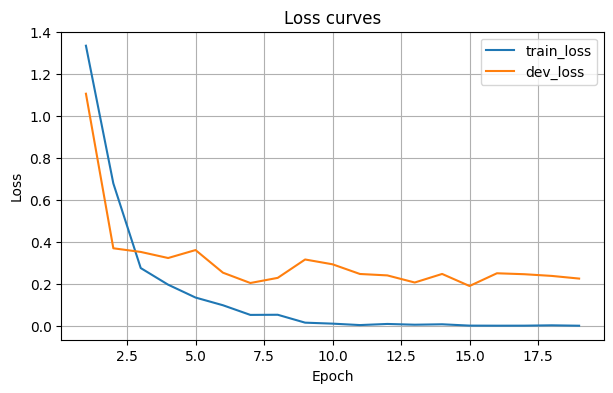

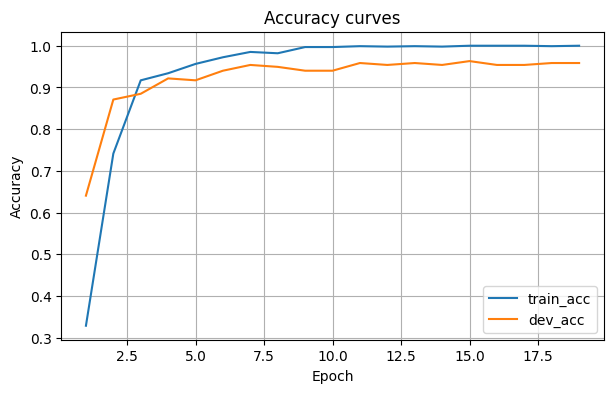

In [12]:
xs = list(range(1, len(history["train_loss"]) + 1))

plt.figure(figsize=(7,4))
plt.plot(xs, history["train_loss"], label="train_loss")
plt.plot(xs, history["dev_loss"], label="dev_loss")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("Loss curves")
plt.grid(True); plt.legend(); plt.show()

plt.figure(figsize=(7,4))
plt.plot(xs, history["train_acc"], label="train_acc")
plt.plot(xs, history["dev_acc"], label="dev_acc")
plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.title("Accuracy curves")
plt.grid(True); plt.legend(); plt.show()

Dev confusion matrix + report

DEV: {'loss': 0.18967529406238878, 'acc': 0.9631336405529954}


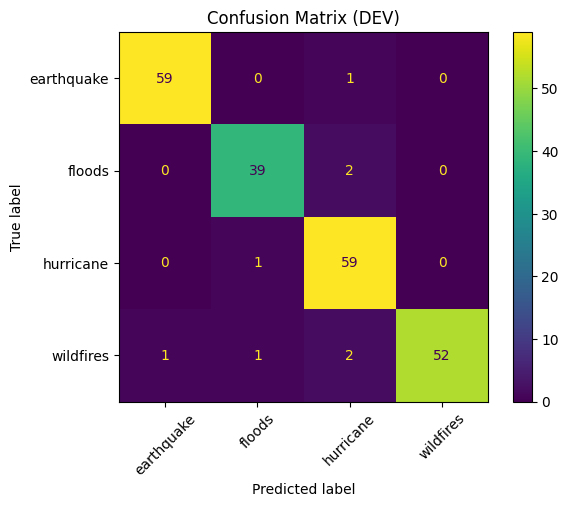

              precision    recall  f1-score   support

  earthquake     0.9833    0.9833    0.9833        60
      floods     0.9512    0.9512    0.9512        41
   hurricane     0.9219    0.9833    0.9516        60
   wildfires     1.0000    0.9286    0.9630        56

    accuracy                         0.9631       217
   macro avg     0.9641    0.9616    0.9623       217
weighted avg     0.9646    0.9631    0.9632       217



In [13]:
# ====== REPLACE: Dev confusion matrix + report cell ======
dev_loss, dev_acc, y_true, y_pred = evaluate(model, dev_loader, criterion)
print("DEV:", {"loss": dev_loss, "acc": dev_acc})

cm = confusion_matrix(y_true, y_pred, labels=list(range(num_classes)))
disp = ConfusionMatrixDisplay(cm, display_labels=[id2label[i] for i in range(num_classes)])
disp.plot(xticks_rotation=45, values_format="d")
plt.title("Confusion Matrix (DEV)")
plt.show()

print(classification_report(
    y_true, y_pred,
    target_names=[id2label[i] for i in range(num_classes)],
    digits=4
))

Test confusion matrix + report

TEST: {'loss': 0.1623503119975794, 'acc': 0.9657534246575342}


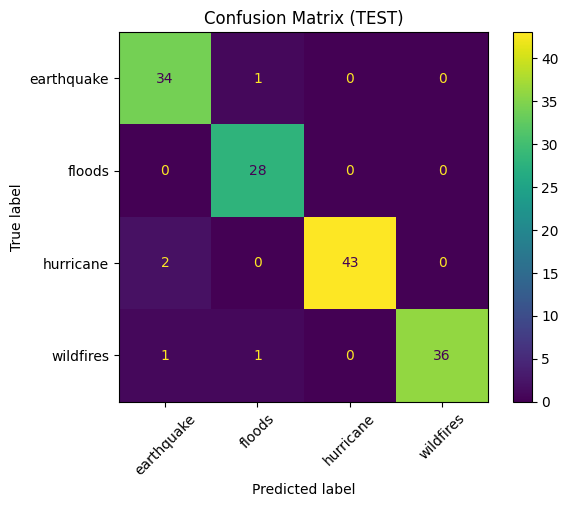

              precision    recall  f1-score   support

  earthquake     0.9189    0.9714    0.9444        35
      floods     0.9333    1.0000    0.9655        28
   hurricane     1.0000    0.9556    0.9773        45
   wildfires     1.0000    0.9474    0.9730        38

    accuracy                         0.9658       146
   macro avg     0.9631    0.9686    0.9651       146
weighted avg     0.9678    0.9658    0.9660       146



In [14]:
# ====== REPLACE: Test confusion matrix + report cell ======
test_loss, test_acc, y_true_t, y_pred_t = evaluate(model, test_loader, criterion)
print("TEST:", {"loss": test_loss, "acc": test_acc})

cm = confusion_matrix(y_true_t, y_pred_t, labels=list(range(num_classes)))
disp = ConfusionMatrixDisplay(cm, display_labels=[id2label[i] for i in range(num_classes)])
disp.plot(xticks_rotation=45, values_format="d")
plt.title("Confusion Matrix (TEST)")
plt.show()

print(classification_report(
    y_true_t, y_pred_t,
    target_names=[id2label[i] for i in range(num_classes)],
    digits=4
))

Prediction utility (label + probs)

In [15]:
@torch.no_grad()
def predict_one(text: str):
    model.eval()
    ct = clean_tweet(text)
    ids = [BOS_ID] + sp.encode_as_ids(ct) + [EOS_ID]
    ids = ids[:MAX_LEN]
    attn = [1]*len(ids)

    input_ids = torch.tensor(ids, dtype=torch.long).unsqueeze(0).to(device)
    attention_mask = torch.tensor(attn, dtype=torch.long).unsqueeze(0).to(device)

    logits = model(input_ids, attention_mask)
    probs = torch.softmax(logits, dim=1).squeeze(0).cpu().numpy()
    pred_id = int(probs.argmax())
    return pred_id, id2label[pred_id], {id2label[i]: float(probs[i]) for i in range(num_classes)}, ct

pid, plabel, pprobs, cleaned = predict_one("Massive flooding after heavy rain in Colombo")
print("cleaned:", cleaned)
print("pred:", pid, plabel)
print("probs:", pprobs)

cleaned: massive flooding after heavy rain in colombo
pred: 2 hurricane
probs: {'earthquake': 0.10214626044034958, 'floods': 0.02423824556171894, 'hurricane': 0.8434586524963379, 'wildfires': 0.03015691414475441}


Save model + tokenizer + mapping

In [16]:
SAVE_DIR = "/content/drive/MyDrive/TASK01/models/custom_transformer_spm_4class_acc"
os.makedirs(SAVE_DIR, exist_ok=True)

torch.save(model.state_dict(), os.path.join(SAVE_DIR, "model.pt"))

with open(os.path.join(SAVE_DIR, "label2id.json"), "w") as f:
    json.dump(label2id, f, indent=2)

with open(os.path.join(SAVE_DIR, "config.json"), "w") as f:
    json.dump({
        "vocab_size": vocab_size,
        "num_classes": num_classes,
        "MAX_LEN": MAX_LEN,
        "d_model": 320,
        "n_layers": 6,
        "n_heads": 8,
        "d_ff": 1280,
        "dropout": 0.15,
        "VOCAB_SIZE": VOCAB_SIZE,
        "spm_model": spm_prefix + ".model"
    }, f, indent=2)

print("Saved to:", SAVE_DIR)
print("Tokenizer saved at:", SP_DIR)

Saved to: /content/drive/MyDrive/TASK01/models/custom_transformer_spm_4class_acc
Tokenizer saved at: /content/drive/MyDrive/TASK01/models/spm_tokenizer_4class


In [3]:
import torch
import json
import sentencepiece as spm
import os

# ========= PATHS =========
SAVE_DIR = "/content/drive/MyDrive/TASK01/models/custom_transformer_spm_4class_acc"
SP_DIR   = "/content/drive/MyDrive/TASK01/models/spm_tokenizer_4class"

MODEL_PATH = os.path.join(SAVE_DIR, "model.pt")
CONFIG_PATH = os.path.join(SAVE_DIR, "config.json")
LABEL_PATH = os.path.join(SAVE_DIR, "label2id.json")
SPM_MODEL_PATH = os.path.join(SP_DIR, "tweet_bpe.model")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ========= LOAD CONFIG =========
with open(CONFIG_PATH, "r") as f:
    config = json.load(f)

with open(LABEL_PATH, "r") as f:
    label2id = json.load(f)

id2label = {int(v): k for k, v in label2id.items()}

MAX_LEN = config["MAX_LEN"]
PAD_ID = 0
BOS_ID = 2
EOS_ID = 3

# ========= LOAD TOKENIZER =========
sp = spm.SentencePieceProcessor()
sp.load(SPM_MODEL_PATH)

# ========= REBUILD MODEL =========
class TransformerEncoderBlock(torch.nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.ln1 = torch.nn.LayerNorm(d_model)
        self.attn = torch.nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=n_heads,
            dropout=dropout,
            batch_first=True
        )
        self.drop1 = torch.nn.Dropout(dropout)

        self.ln2 = torch.nn.LayerNorm(d_model)
        self.ff = torch.nn.Sequential(
            torch.nn.Linear(d_model, d_ff),
            torch.nn.GELU(),
            torch.nn.Dropout(dropout),
            torch.nn.Linear(d_ff, d_model)
        )
        self.drop2 = torch.nn.Dropout(dropout)

    def forward(self, x, key_padding_mask):
        h = self.ln1(x)
        attn_out, _ = self.attn(h, h, h, key_padding_mask=key_padding_mask, need_weights=False)
        x = x + self.drop1(attn_out)

        h = self.ln2(x)
        x = x + self.drop2(self.ff(h))
        return x


class DisasterTweetTransformer(torch.nn.Module):
    def __init__(self, vocab_size, num_classes, max_len,
                 d_model, n_layers, n_heads, d_ff, dropout):
        super().__init__()
        self.max_len = max_len
        self.tok_emb = torch.nn.Embedding(vocab_size, d_model, padding_idx=PAD_ID)
        self.pos_emb = torch.nn.Embedding(max_len, d_model)
        self.drop = torch.nn.Dropout(dropout)

        self.blocks = torch.nn.ModuleList([
            TransformerEncoderBlock(d_model, n_heads, d_ff, dropout)
            for _ in range(n_layers)
        ])
        self.ln = torch.nn.LayerNorm(d_model)

        self.pool_score = torch.nn.Linear(d_model, 1)

        self.classifier = torch.nn.Sequential(
            torch.nn.Linear(d_model, d_model),
            torch.nn.GELU(),
            torch.nn.Dropout(dropout),
            torch.nn.Linear(d_model, num_classes),
        )

    def forward(self, input_ids, attention_mask):
        B, T = input_ids.shape

        if T > self.max_len:
            input_ids = input_ids[:, :self.max_len]
            attention_mask = attention_mask[:, :self.max_len]
            T = self.max_len

        pos = torch.arange(T, device=input_ids.device).unsqueeze(0).expand(B, T)

        x = self.tok_emb(input_ids) + self.pos_emb(pos)
        x = self.drop(x)

        key_padding_mask = (attention_mask == 0).bool()

        for blk in self.blocks:
            x = blk(x, key_padding_mask)

        x = self.ln(x)

        scores = self.pool_score(x).squeeze(-1)

        if scores.dtype == torch.float16:
            mask_value = -1e4
        else:
            mask_value = -1e9

        scores = scores.masked_fill(key_padding_mask, mask_value)
        w = torch.softmax(scores, dim=1).unsqueeze(-1)
        pooled = torch.sum(x * w, dim=1)

        return self.classifier(pooled)


model = DisasterTweetTransformer(
    vocab_size=config["vocab_size"],
    num_classes=config["num_classes"],
    max_len=config["MAX_LEN"],
    d_model=config["d_model"],
    n_layers=config["n_layers"],
    n_heads=config["n_heads"],
    d_ff=config["d_ff"],
    dropout=config["dropout"]
).to(device)

model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()

print("✅ Model loaded successfully")

✅ Model loaded successfully


In [4]:
def predict_text(text):
    model.eval()
    # encode
    ids = [BOS_ID] + sp.encode_as_ids(text.lower()) + [EOS_ID]
    ids = ids[:MAX_LEN]
    attn = [1] * len(ids)

    input_ids = torch.tensor(ids).unsqueeze(0).to(device)
    attention_mask = torch.tensor(attn).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(input_ids, attention_mask)
        probs = torch.softmax(logits, dim=1).cpu().numpy()[0]

    pred_id = int(probs.argmax())
    pred_label = id2label[pred_id]

    print("\nInput Text:")
    print(text)
    print("\nPrediction:", pred_label)
    print("Probabilities:")
    for i in range(len(probs)):
        print(f"{id2label[i]}: {probs[i]:.4f}")

In [8]:
predict_text("Hank visits local restaurant to discuss the U.S. response to Hurricane Maria devastation https://t.co/f6bfKpYPOB https://t.co/8P2mj3fj6f")


Input Text:
Hank visits local restaurant to discuss the U.S. response to Hurricane Maria devastation https://t.co/f6bfKpYPOB https://t.co/8P2mj3fj6f

Prediction: hurricane
Probabilities:
earthquake: 0.0002
floods: 0.0007
hurricane: 0.9990
wildfires: 0.0002
